In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier

RNG = 42
np.random.seed(RNG)

Por organización, en este nuevo notebook hacemos el clasificador como una función para obtener los resultados de forma más rápida y organizada. 

In [9]:
# cargar dataframe y separar en X, y, T, m, realizacion
datos = np.load("Datos/ising_dataset.npz", allow_pickle=False)
X = datos["X"]
y = datos["y"]
T = datos["T"]
m = datos["m"]
realizacion = datos["realizacion"]

Tc_exacto = float(datos["Tc"])
L = int(datos["L"])

print("X:", X.shape, X.dtype)
print("y:", y.shape, "->", np.unique(y, return_counts=True))
print("realizaciones:", np.unique(realizacion))
print("Tc exacto (Onsager):", Tc_exacto)

# la función para estimar Tc por Interpolación
def cruce_05(temps, probs):
    temps, probs = np.asarray(temps), np.asarray(probs)
    for i in range(len(temps) - 1):
        if (probs[i] - 0.5) * (probs[i + 1] - 0.5) <= 0 and probs[i + 1] != probs[i]:
            return (temps[i] + (0.5 - probs[i]) *
                    (temps[i + 1] - temps[i]) / (probs[i + 1] - probs[i]))
    return np.nan

X: (1600, 16, 16) int8
y: (1600,) -> (array([0, 1], dtype=int8), array([800, 800]))
realizaciones: [0 1 2 3]
Tc exacto (Onsager): 2.269185314213022


In [10]:
# calcular máscaras para separar los datos en train, val y test (igual que en notebook 07_cLab_TcEstudiante.ipynb)
mask_train = np.isin(realizacion, [0, 1])
mask_val   = realizacion == 2
mask_test  = realizacion == 3

def aplanar(A):
    return A.reshape(A.shape[0], L * L)

X_train, y_train, T_train = aplanar(X[mask_train]), y[mask_train], T[mask_train]
X_val,   y_val,   T_val   = aplanar(X[mask_val]),   y[mask_val],   T[mask_val]
X_test,  y_test,  T_test  = aplanar(X[mask_test]),  y[mask_test],  T[mask_test]

for nombre, Xs, ys in [("train", X_train, y_train),
                       ("val",   X_val,   y_val),
                       ("test",  X_test,  y_test)]:
    print(f"{nombre:5s}  X={Xs.shape}  y={ys.shape}  clases={np.bincount(ys)}")

train  X=(800, 256)  y=(800,)  clases=[400 400]
val    X=(400, 256)  y=(400,)  clases=[200 200]
test   X=(400, 256)  y=(400,)  clases=[200 200]


## 8.1:  Análisis crítico

Responde en celdas de texto, con evidencia (números o gráficas de tu notebook):

1. **Sesgo del estimador.** El $T_c$ estimado suele quedar *por debajo* de Onsager
   ($\approx 2.23$ vs $2.269$). Menciona al menos dos causas: tamaño finito $L=16$, definición
   de la etiqueta `y`, rango de temperaturas de entrenamiento, uso del umbral fijo 0.5.

- El resultado de Onsager corresponde al límite termodinámco de una red infinita $L \to \infty$. En nuestro sistema de $16 \times 16$, los efectos de tamaño finito afectan las propiedas de transición al rededor del valor teórico de $T_c$.

- Así mismo, tenemos un gran hueco en los datos de temperatura, entre 1.9 y 2.6. Nuestro modelo está aprendiendo que pasa en las regiones de alta y baja temperatura, donde las fases están más o menos bien determinadas. Sin embargo, al preguntarle por la región al rededor de $T_c$, el clasificador tiene que hacer un tipo de extrapolación.

- Finalmente, el uso del umbral fijo de $0.5$ es razonable para nuestra clasficación binaria, sin embargo, no es algo que se deduzca físicamente.


## 8.2 Arquitectura 

In [11]:
#=========================================================================
# función para entrenar un MLP y estimar Tc
#=========================================================================
'''le daamos hidden_layers_sizes como parametro, tambien random_state, y un booleano para
definir si se usa  prob_media o pred mean,  y la opción de graficar plots. El código es esencialmente el mismo'''

def entrenar_mlp(hidden_layer_sizes, random_state=RNG, prob_media=True, plots=True,):
    model = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=random_state,
    )
    
    model.fit(X_train, y_train)

    acc = {
        "train": model.score(X_train, y_train),
        "val":   model.score(X_val, y_val),
        "test":  model.score(X_test, y_test),
    }

    print(f"Arquitectura: {hidden_layer_sizes}")
    print(f"iteraciones: {model.n_iter_}   log-loss final: {model.loss_:.4f}")
    
    for k, v in acc.items():
        print(f"accuracy {k:5s}: {v:.4f}")

    #=========================================================================
    # barrido fino al rededor de Tc
    datos_tc = np.load("Datos/temperatura_critica.npz", allow_pickle=False)
    X_tc = datos_tc["X"].reshape(datos_tc["X"].shape[0], L * L)
    T_tc = datos_tc["T"]
    realizacion_tc = datos_tc["realizacion"]
    y_ref_tc = datos_tc["y_ref"]

    print("\n" + "=" * 64)
    print("X_tc:", X_tc.shape)
    print("temperaturas:", np.unique(T_tc))

    # Probabilidad de la clase "desordenada" (y = 1)
    idx1 = list(model.classes_).index(1)
    p1_tc = model.predict_proba(X_tc)[:, idx1]

    # Chequeo con y_ref (NO usar para entrenar)
    pred_tc = (p1_tc >= 0.5).astype(int)
    print("accuracy vs y_ref (solo verificacion):",
        round((pred_tc == y_ref_tc).mean(), 4))


    #=========================================================================
    # Data frame para curva de probabilidad vs temperatura
    if prob_media:
        df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "prob": p1_tc})

        resumen = (df.groupby(["realizacion", "T"])
                    .agg(prob_media=("prob", "mean"),
                        prob_std=("prob", "std"),
                        N=("prob", "size"))
                    .reset_index())
    else:
        df = pd.DataFrame({"T": T_tc, "realizacion": realizacion_tc, "pred": pred_tc})

        resumen = (df.groupby(["realizacion", "T"])
                    .agg(pred_media=("pred", "mean"),
                        pred_std=("pred", "std"),
                        N=("pred", "size"))
                    .reset_index())


    #=========================================================================
    # Estimación de Tc por cada realización
    Tc_por_realizacion = []
    for r in np.unique(realizacion_tc):
        d = resumen[resumen.realizacion == r].sort_values("T")
        if prob_media:
            Tc_r = cruce_05(d["T"].to_numpy(), d["prob_media"].to_numpy())
        else:
            Tc_r = cruce_05(d["T"].to_numpy(), d["pred_media"].to_numpy())
    
        Tc_por_realizacion.append(Tc_r)
        print(f"realización {r}:  Tc = {Tc_r:.4f}")

    Tc_por_realizacion = np.array(Tc_por_realizacion)
    Tc_est = np.nanmean(Tc_por_realizacion)
    Tc_std = np.nanstd(Tc_por_realizacion, ddof=1)
    Tc_sem = Tc_std / np.sqrt(np.sum(~np.isnan(Tc_por_realizacion)))

    print("\n" + "=" * 64)
    print(f"Tc estimado    = {Tc_est:.4f} +/- {Tc_sem:.4f}")
    print(f"Tc Onsager     = {Tc_exacto:.4f}")
    print(f"error relativo = {100 * abs(Tc_est - Tc_exacto) / Tc_exacto:.2f} %")

    #==========================================================================
    # graficas
    # perdida 
    if plots:
        fig, ax = plt.subplots(1, 3, figsize=(20, 6))
        ax[0].plot(model.loss_curve_)
        ax[0].set_xlabel("época")
        ax[0].set_ylabel("log-loss (entrenamiento)")
        ax[0].set_title(f"Curva de pérdida — {hidden_layer_sizes}")
        ax[0].grid(alpha=0.3)

        # Probabilidad vs temperatura
        ax[1].set_title("Probabilidad de la clase desordenada (y=1) vs Temperatura")
        ax[1].set_xlabel("Temperatura")
        ax[1].set_ylabel("<Probabilidad>")
        ax[1].plot(
            resumen["T"],
            resumen["prob_media"],
            'o',
            markersize=3,
            label="Probabilidad media"
        )
        ax[1].legend()

        # ─────────────────────────────
        for r in np.unique(realizacion_tc):

            d = resumen[resumen.realizacion == r].sort_values("T")

            ax[2].plot(d["T"],d["prob_media"],"o-", alpha=0.7, label=f"realización {r}")
            ax[2].axhline(0.5, ls="--", color="k")

            ax[2].axvline(Tc_est, ls="-", color="crimson", lw=2, label=fr"$T_c$ estimado = {Tc_est:.3f}")

        ax[2].axvline(Tc_exacto,ls=":",color="green",lw=2, label=fr"$T_c$ Onsager = {Tc_exacto:.3f}")

        ax[2].set_xlabel("temperatura T")
        ax[2].set_ylabel(r"$\langle P(y=1\mid X)\rangle$")
        ax[2].set_title("Estimación de la temperatura crítica")
        ax[2].legend()
        ax[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return model, acc, realizacion_tc, resumen, Tc_est, Tc_std, Tc_sem

Arquitectura: (16, 8, 4)
iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8247
realización 0:  Tc = 2.2403
realización 1:  Tc = 2.2204
realización 2:  Tc = 2.2149
realización 3:  Tc = 2.2280

Tc estimado    = 2.2259 +/- 0.0055
Tc Onsager     = 2.2692
error relativo = 1.91 %


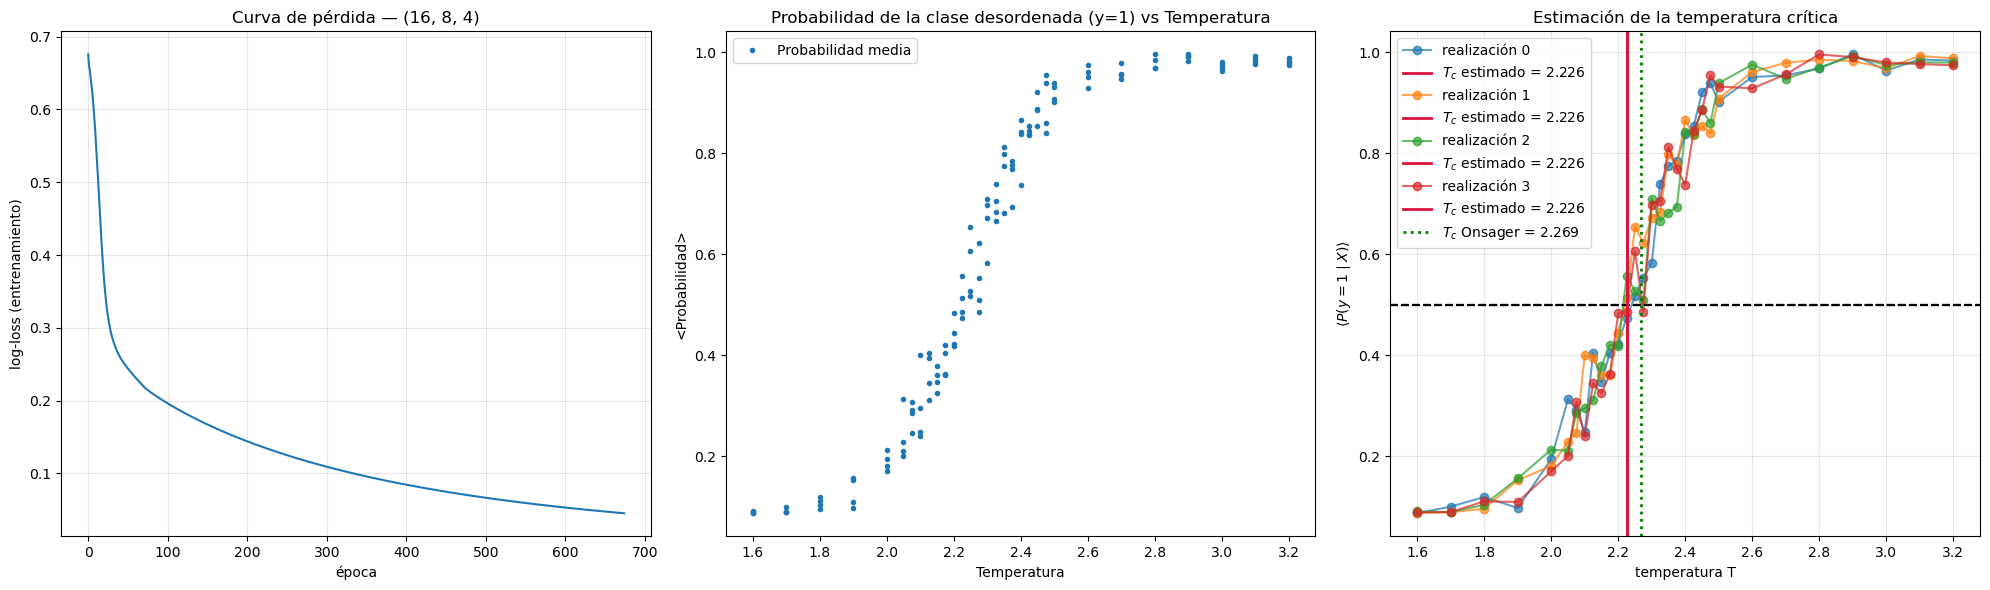

In [22]:
# modelo original, con (16, 8, 4) como arquitectura de la red
model_168,acc_168,realizacion_168,resumen_168,Tc_est_168,Tc_std_168,Tc_sem_168 = entrenar_mlp((16,8,4), random_state=RNG, prob_media=True, plots=True)

Arquitectura: (64,)
iteraciones: 95   log-loss final: 0.0037
accuracy train: 1.0000
accuracy val  : 0.9750
accuracy test : 0.9675

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8095
realización 0:  Tc = 2.3616
realización 1:  Tc = 2.3443
realización 2:  Tc = 2.3832
realización 3:  Tc = 2.4052

Tc estimado    = 2.3736 +/- 0.0132
Tc Onsager     = 2.2692
error relativo = 4.60 %


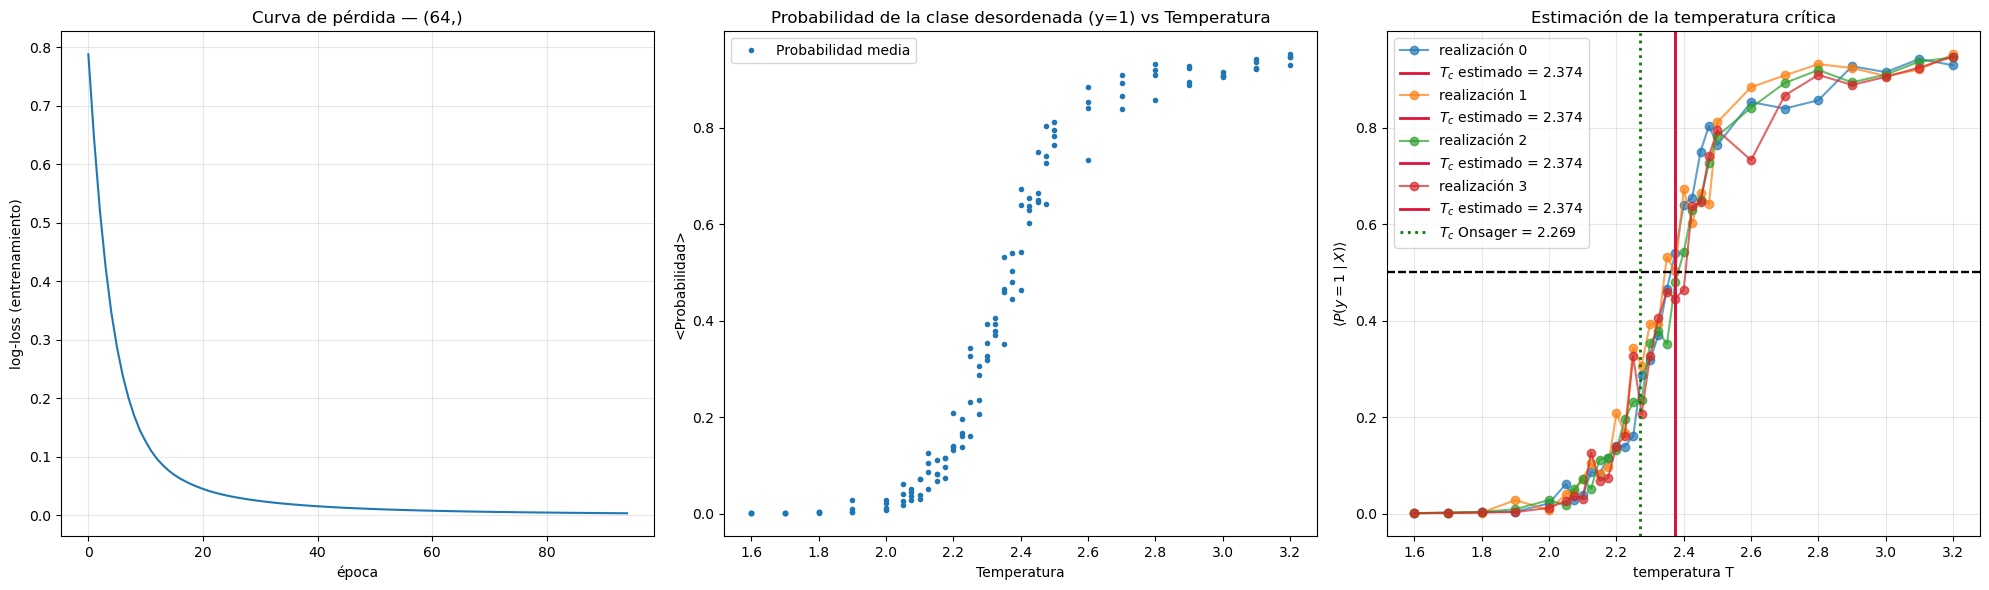

In [13]:
# modelo con una sola capa oculta de 64 neuronas
model_64, acc_64, realizacion_64, resumen_64, Tc_est_64, Tc_std_64, Tc_sem_64 = entrenar_mlp((64,), random_state=RNG, prob_media=True, plots=True)

Arquitectura: (32, 16, 8)
iteraciones: 80   log-loss final: 0.0019
accuracy train: 1.0000
accuracy val  : 0.9800
accuracy test : 0.9850

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8118
realización 0:  Tc = 2.3667
realización 1:  Tc = 2.3487
realización 2:  Tc = 2.3808
realización 3:  Tc = 2.3644

Tc estimado    = 2.3652 +/- 0.0066
Tc Onsager     = 2.2692
error relativo = 4.23 %


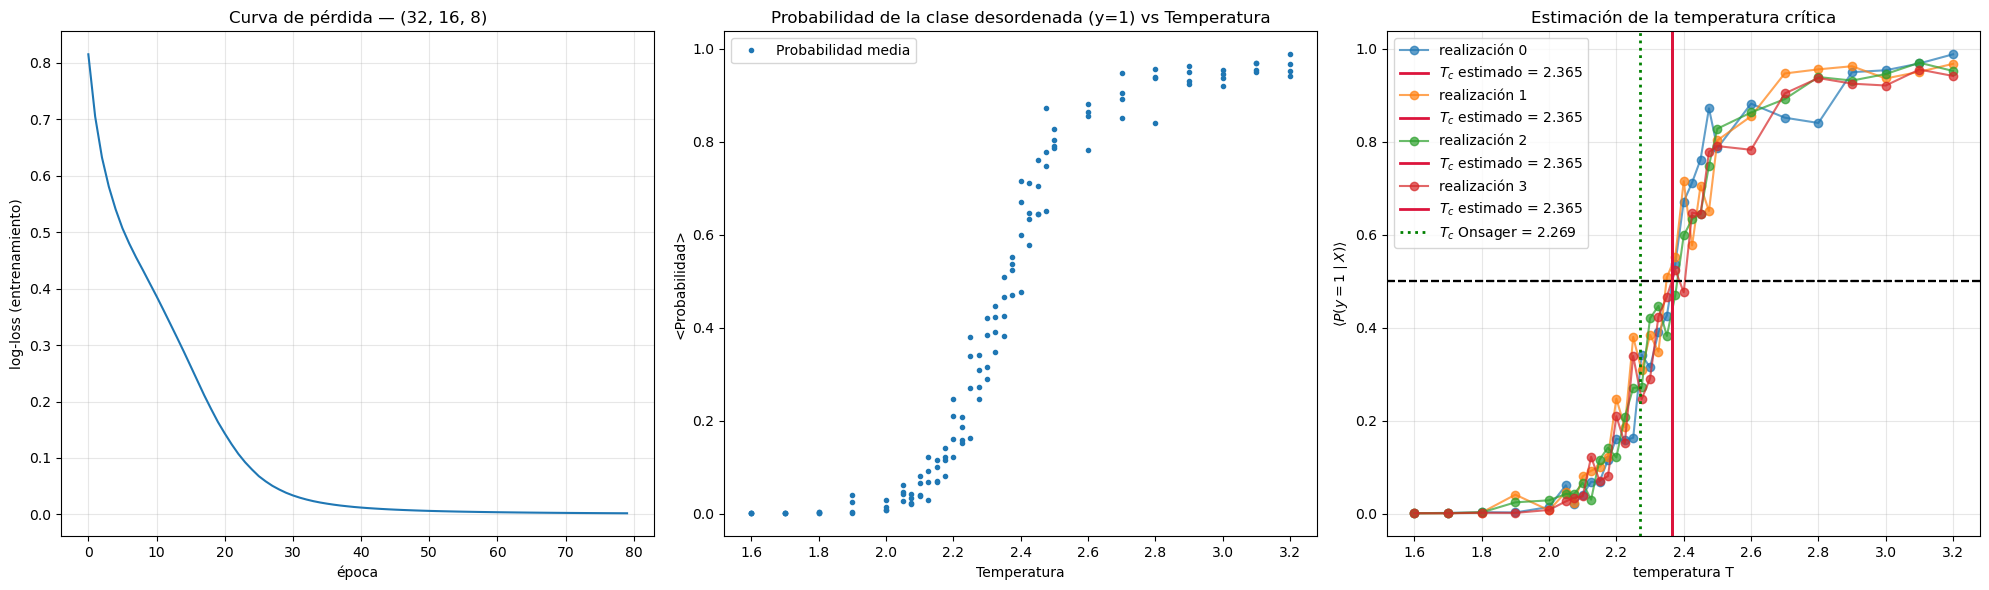

In [14]:
# modelo con ariquitectura (32, 16, 8)
model_328, acc_328, realizacion_328, resumen_328, Tc_est_328, Tc_std_328, Tc_sem_328 = entrenar_mlp((32,16,8), random_state=RNG, prob_media=True, plots=True)

### Comparación de $T_c$ con las diferentes ariquitecturas 

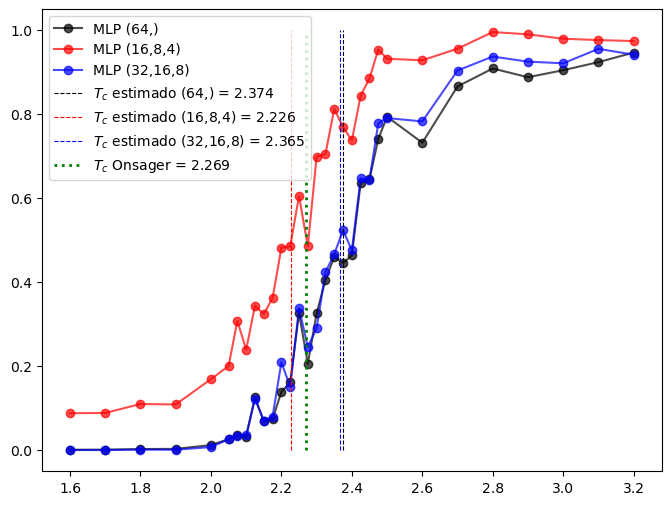

In [15]:
d168 = resumen_168[resumen_168.realizacion == 3].sort_values("T")
d64 = resumen_64[resumen_64.realizacion == 3].sort_values("T")
d328 = resumen_328[resumen_328.realizacion == 3].sort_values("T")

plt.figure(figsize=(8, 6))
plt.plot(d64["T"],d64["prob_media"],"o-", alpha=0.7, color="black", label=("MLP (64,)"))
plt.plot(d168["T"],d168["prob_media"],"o-", alpha=0.7, color="red", label=("MLP (16,8,4)"))
plt.plot(d328["T"],d328["prob_media"],"o-", alpha=0.7, color="blue", label=("MLP (32,16,8)"))
plt.vlines(Tc_est_64, 0.0, 1.0, ls="--", color="black", lw=0.8, label="$T_c$ estimado (64,) = {:.3f}".format(Tc_est_64))
plt.vlines(Tc_est_168, 0.0, 1.0, ls="--", color="red", lw=0.8, label="$T_c$ estimado (16,8,4) = {:.3f}".format(Tc_est_168))
plt.vlines(Tc_est_328, 0.0, 1.0, ls="--", color="blue", lw=0.8, label="$T_c$ estimado (32,16,8) = {:.3f}".format(Tc_est_328))
plt.vlines(Tc_exacto, 0.0, 1.0, ls=":", color="green", lw=2, label="$T_c$ Onsager = {:.3f}".format(Tc_exacto))
#plt.axhline(0.5, ls="--", color="k")
plt.legend()
plt.show()

Vemos que nuestra arquitectura $(16, 8,4)$ es suficiente para predecir la temperatura crítica con un error menor al $2 \%$. Así mismo, es la que necesita más épocas para optimizar los parámetros. 

En comparación con las otras arquitecturas, $(64,)$ tiene muchos parámetros concetrados en la primera capa oculta. La red puede estar aprendiendo una representación útil, pero la frontera de decisión no está siendo adecuada, y no está cosntruyendo patrones de aprendizaje más complejos.Dado que solo tiene una capa oculta, su log-loss se minimiza rápidamente.

La arquitectura $(32,16,8)$ si bien tiene más capacidad y la misma profundida que la arquitectura inicial, no está mejorando la estimación de $T_c$, quizá debido a que está aprendiendo configuraciones irrelevantes para localizar la transición. 

## 8.3 -  Reproducibilidad: 
    Entrena con 5 semillas distintas (`random_state`) y reporta
   $T_c$ media ± desviación. ¿La dispersión por semilla es mayor o menor que la dispersión
   entre realizaciones?

In [16]:
semillas = [0, 1, 2, 3, 4]

T_semillas = []
for semilla in semillas:
    print("\n" + "+" * 64)
    print(f"Entrenando MLP con semilla {semilla}")
    print( "+" * 64)
    model, acc, realizacion, resumen, Tc_est, Tc_std, Tc_sem = entrenar_mlp((16,8,4),random_state=semilla,prob_media=True, plots=False)
    T_semillas.append(Tc_est)


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Entrenando MLP con semilla 0
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Arquitectura: (16, 8, 4)
iteraciones: 144   log-loss final: 0.0032
accuracy train: 1.0000
accuracy val  : 0.9750
accuracy test : 0.9700

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8152
realización 0:  Tc = 2.3529
realización 1:  Tc = 2.3393
realización 2:  Tc = 2.3670
realización 3:  Tc = 2.3720

Tc estimado    = 2.3578 +/- 0.0074
Tc Onsager     = 2.2692
error relativo = 3.91 %

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Entrenando MLP con semilla 1
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Arquitectura: (16, 8, 4)
iteraciones: 91   log-loss final: 0.0016
accuracy train: 1

In [17]:
T_semillas = np.array(T_semillas)
print("Tc semillas: ", T_semillas)
Tc_mean = np.mean(T_semillas)
Tc_std = np.std(T_semillas)
print(f"\nPromedio de Tc estimado: {Tc_mean:.4f} +/- {Tc_std:.4f} (desviación estándar)")
print("Dispersion de Tc estimado por semillas: ", np.std(T_semillas, ddof=1))
print(f"dispersión por realización = {Tc_std_168:.4f}")


Tc semillas:  [2.35781194 2.36332686 2.36187877 2.27669766 2.35826528]

Promedio de Tc estimado: 2.3436 +/- 0.0335 (desviación estándar)
Dispersion de Tc estimado por semillas:  0.037470770276300726
dispersión por realización = 0.0110


La dispersión entre realizaciones es algo mejor al caso por semillas. El resultado es estable frente a diferentes realizaciones del sistema, mientras que inicializaciones aleatorias de la red pueden inducir pequeñas variaciones que afectan más a $T_c$.

## 8.4 - Definición alternativa: 
Usa la *fracción de configuraciones clasificadas como fase 1*
   (`pred.mean()` por $T$) en vez de `prob_media`. ¿Obtienes el mismo $T_c$?

In [18]:
# definicion alternativa para arqitectura (16,8,4)
model_168_alt,acc_168_alt,realizacion_168_alt,resumen_168_alt,Tc_est_168_alt,Tc_std_168_alt,Tc_sem_168_alt = entrenar_mlp((16,8,4), random_state=RNG, prob_media=False, plots=False)

Arquitectura: (16, 8, 4)
iteraciones: 675   log-loss final: 0.0453
accuracy train: 1.0000
accuracy val  : 0.9850
accuracy test : 0.9875

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8247
realización 0:  Tc = 2.2500
realización 1:  Tc = 2.2250
realización 2:  Tc = 2.2200
realización 3:  Tc = 2.2375

Tc estimado    = 2.2331 +/- 0.0067
Tc Onsager     = 2.2692
error relativo = 1.59 %


In [19]:
# definición alternativa arquitectura (64,) 
model_64_alt,acc_64_alt,realizacion_64_alt,resumen_64_alt,Tc_est_64_alt,Tc_std_64_alt,Tc_sem_64_alt=entrenar_mlp((64,),random_state=RNG,prob_media=False,plots=False)

Arquitectura: (64,)
iteraciones: 95   log-loss final: 0.0037
accuracy train: 1.0000
accuracy val  : 0.9750
accuracy test : 0.9675

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8095
realización 0:  Tc = 2.3750
realización 1:  Tc = 2.3417
realización 2:  Tc = 2.3875
realización 3:  Tc = 2.4100

Tc estimado    = 2.3785 +/- 0.0143
Tc Onsager     = 2.2692
error relativo = 4.82 %


In [20]:
# definición alternativa arquitectura (32,16,8) 
model_328_alt,acc_328_alt,realizacion_328_alt,resumen_328_alt,Tc_est_328_alt,Tc_std_328_alt,Tc_sem_328_alt = entrenar_mlp((32,16,8), random_state=RNG, prob_media=False, plots=False)

Arquitectura: (32, 16, 8)
iteraciones: 80   log-loss final: 0.0019
accuracy train: 1.0000
accuracy val  : 0.9800
accuracy test : 0.9850

X_tc: (6200, 256)
temperaturas: [1.6   1.7   1.8   1.9   2.    2.05  2.075 2.1   2.125 2.15  2.175 2.2
 2.225 2.25  2.275 2.3   2.325 2.35  2.375 2.4   2.425 2.45  2.475 2.5
 2.6   2.7   2.8   2.9   3.    3.1   3.2  ]
accuracy vs y_ref (solo verificacion): 0.8118
realización 0:  Tc = 2.3708
realización 1:  Tc = 2.3500
realización 2:  Tc = 2.3786
realización 3:  Tc = 2.3750

Tc estimado    = 2.3686 +/- 0.0064
Tc Onsager     = 2.2692
error relativo = 4.38 %


In [21]:
# comparación de Tc con las dos definiciones
print("Ariquitectura (16,8,4)")
print(f"Tc original = {Tc_est_168:.4f} +/- {Tc_std_168:.4f} ")
print(f"Tc alternativa = {Tc_est_168_alt:.4f} +/- {Tc_std_168_alt:.4f} ")

print("\n" + "=" * 64)

print("Ariquitectura (64,)")
print(f"Tc original = {Tc_est_64:.4f} +/- {Tc_std_64:.4f} ")
print(f"Tc alternativa = {Tc_est_64_alt:.4f} +/- {Tc_std_64_alt:.4f} ")

print("\n" + "=" * 64)

print("Ariquitectura (32,16,8)")
print(f"Tc original = {Tc_est_328:.4f} +/- {Tc_std_328:.4f} ")
print(f"Tc alternativa = {Tc_est_328_alt:.4f} +/- {Tc_std_328_alt:.4f} ")


Ariquitectura (16,8,4)
Tc original = 2.2259 +/- 0.0110 
Tc alternativa = 2.2331 +/- 0.0134 

Ariquitectura (64,)
Tc original = 2.3736 +/- 0.0264 
Tc alternativa = 2.3785 +/- 0.0285 

Ariquitectura (32,16,8)
Tc original = 2.3652 +/- 0.0131 
Tc alternativa = 2.3686 +/- 0.0128 


Los valores de $T_c$ son diferentes pero cercanos calculados con la definición alternativa. Esto indica que la estimación de la temperatura crítica es bastante robusta frente a la definición utilizada para promediar la salida de la red.

### 8.5. ¿Por qué StandardScaler puede no ayudar?

StandarScaler transforma cada característica como $z = (x - \mu) / \sigma $. Esto es muy útil cuando tenemos variables en escalas muy diferentes (como podría ser por ejemplo la temperatura, la energía , la masa) . Sin embargo, aquí nuestros spines ya están entre $-1$ y $+1$, por lo que un scaaling realmente no ayuda a corregir.